In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

In [5]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv


In [6]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [7]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [8]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1470, 35)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [10]:
print(df["Attrition"].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [11]:
attrition_rate = (df["Attrition"] == "Yes").mean() * 100

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


In [12]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

categorical_cols = df.select_dtypes(include=["object"]).columns

print("Numeric Columns:", len(numeric_cols))
print("Categorical Columns:", len(categorical_cols))

Numeric Columns: 26
Categorical Columns: 9


## Observation

The dataset contains 1,470 employee records. The target variable (Attrition) is imbalanced, with approximately 16% of employees leaving the company and 84% staying. This imbalance should be considered while training machine learning models.

In [13]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [14]:
df.drop(
    columns=[
        "EmployeeNumber",
        "EmployeeCount",
        "Over18",
        "StandardHours"
    ],
    inplace=True
)

In [15]:
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

In [16]:
df = pd.get_dummies(
    df,
    drop_first=True
)

In [17]:
from sklearn.preprocessing import StandardScaler

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [18]:
print(df.shape)

(1470, 45)


# Task 3 - Exploratory Data Analysis (EDA)

In [20]:
df_original = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

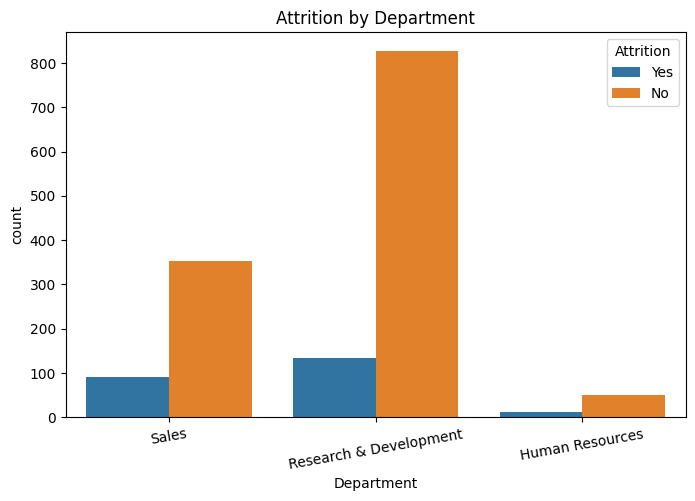

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_original,
    x="Department",
    hue="Attrition"
)

plt.title("Attrition by Department")
plt.xticks(rotation=10)

plt.show()

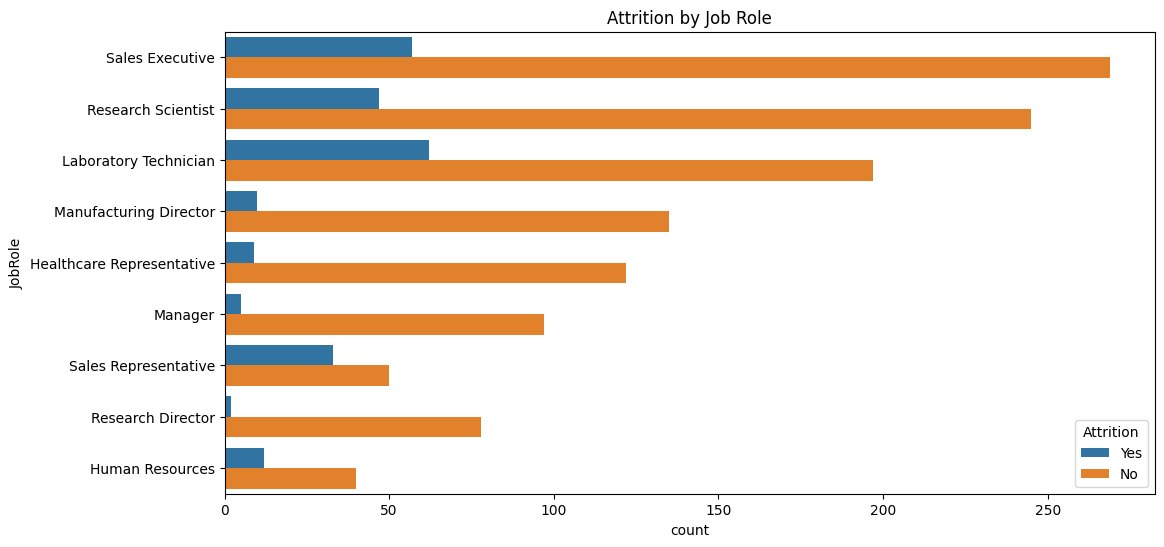

In [22]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df_original,
    y="JobRole",
    hue="Attrition"
)

plt.title("Attrition by Job Role")

plt.show()

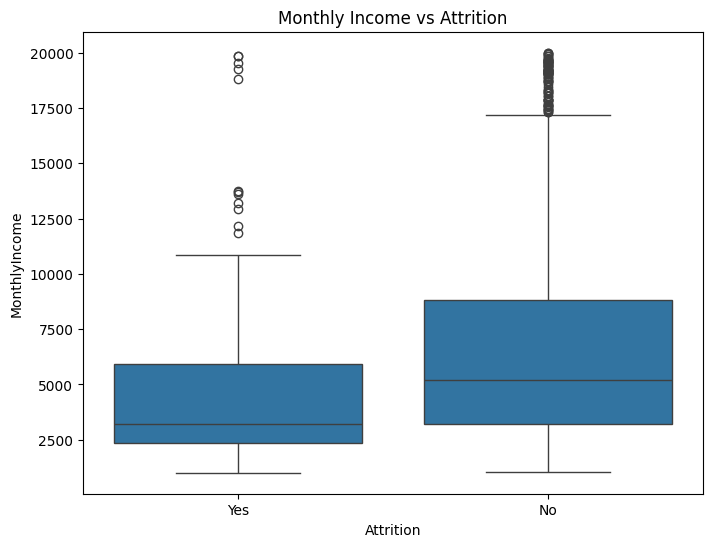

In [23]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_original,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income vs Attrition")

plt.show()

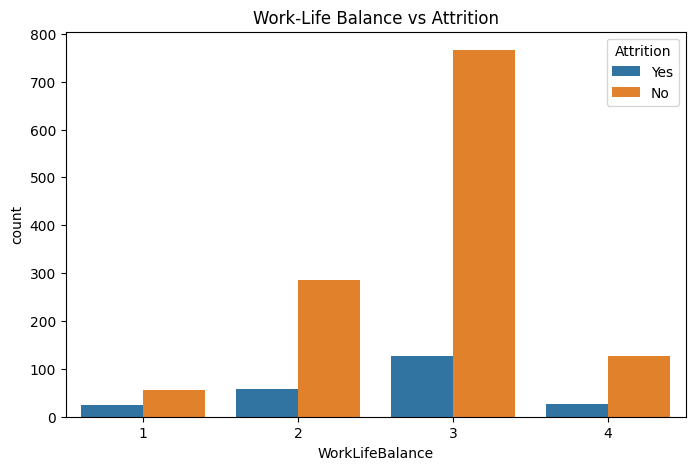

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_original,
    x="WorkLifeBalance",
    hue="Attrition"
)

plt.title("Work-Life Balance vs Attrition")

plt.show()

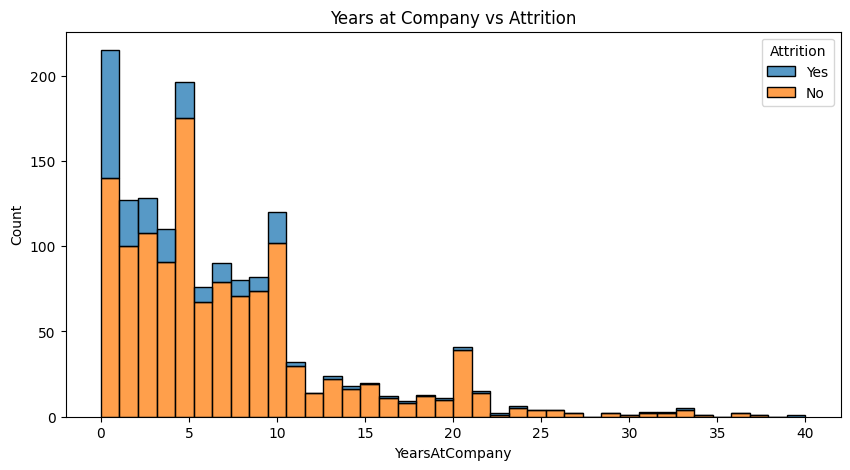

In [25]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df_original,
    x="YearsAtCompany",
    hue="Attrition",
    multiple="stack"
)

plt.title("Years at Company vs Attrition")

plt.show()

## Business Insights

1. Employees in the Sales department show a relatively higher number of attrition cases compared to other departments.

2. Sales Representatives and Laboratory Technicians appear to have the highest employee turnover.

3. Employees with lower monthly income tend to leave more frequently than employees with higher salaries.

4. Employees with lower Work-Life Balance ratings show a higher likelihood of leaving the company.

5. Most employees who leave the company do so within the first few years of employment.

In [26]:
from sklearn.model_selection import train_test_split

# Features and Target
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1176, 44)
(294, 44)


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [28]:
lr = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [29]:
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [30]:
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

results = []

for name, model in models.items():

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)[:,1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

comparison = pd.DataFrame(results)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.748299,0.341176,0.617021,0.439394,0.798605
1,Random Forest,0.833333,0.375000,0.063830,0.109091,0.751917
2,Gradient Boosting,0.850340,0.588235,0.212766,0.312500,0.794125


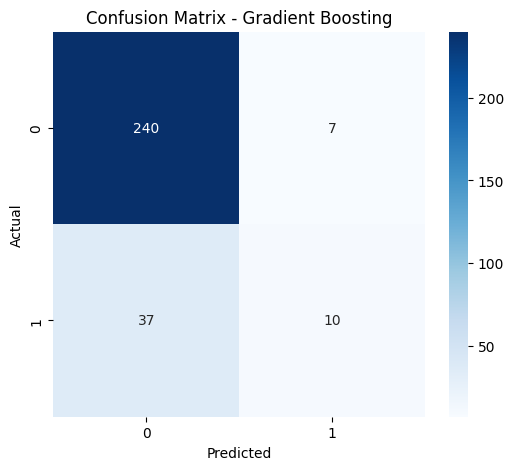

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

pred = gb.predict(X_test)

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png")
plt.show()

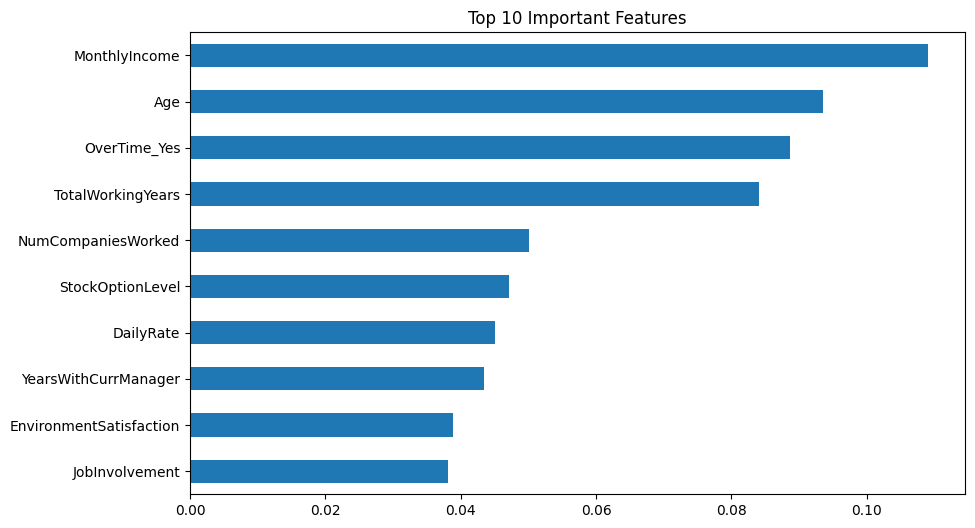

In [33]:
feature_importance = pd.Series(
    gb.feature_importances_,
    index=X.columns
)

top10 = feature_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

top10.sort_values().plot(kind="barh")

plt.title("Top 10 Important Features")

plt.savefig("feature_importance.png")

plt.show()

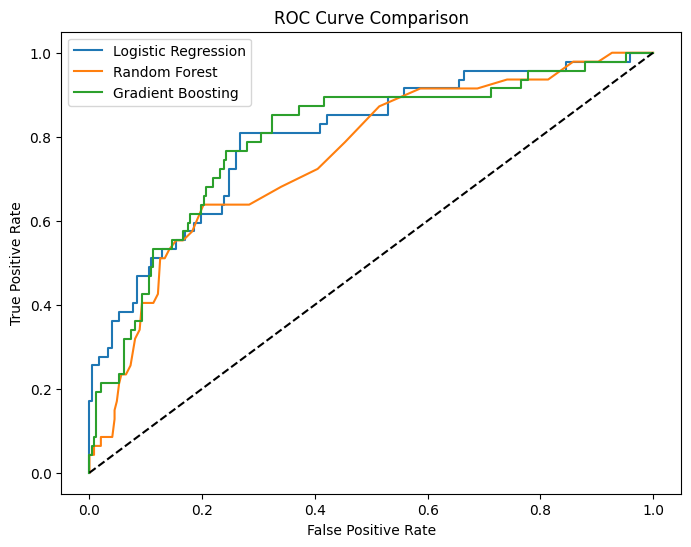

In [34]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

for name, model in models.items():

    probs = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, probs)

    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.savefig("roc_curve.png")

plt.show()

# HR Insights & Business Recommendations

The analysis indicates that employee attrition is influenced by several factors rather than salary alone. Employees with lower job satisfaction, poor work-life balance, fewer years at the company, and lower monthly income are more likely to leave. Sales Representatives and Laboratory Technicians show relatively higher attrition and should be prioritized for retention efforts. Although salary contributes to attrition, factors such as job satisfaction and work-life balance appear to have a stronger impact.

To reduce employee turnover, HR should conduct regular engagement and satisfaction surveys, especially for employees in high-risk job roles. The company should also strengthen work-life balance initiatives, career development opportunities, and retention discussions during the first few years of employment.

One limitation of this model is that it is based on historical employee data and may not capture future organizational changes or personal reasons for leaving. Therefore, it should support HR decision-making rather than replace human judgment.